<a href="https://colab.research.google.com/github/vinothkumard2006-ai/data-science/blob/main/Credict_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Mounted at /content/drive


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset',
 'data_for_preprocessing.csv',
 'Traffic Sign Recognition for Autonomous Vehicle',
 'credict card fraud detection']

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
print(os.listdir('/content/drive/MyDrive/credict card fraud detection'))

['creditcard.csv']


**step 1** : Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve,accuracy_score,f1_score


In [6]:
base_path = "/content/drive/MyDrive/credict card fraud detection"

In [7]:
Credit_card_fraud = pd.read_csv(base_path + "/creditcard.csv")
Credit_card_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
Credit_card_fraud.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [9]:
Credit_card_fraud.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
Credit_card_fraud.shape

(284807, 31)

In [11]:
Credit_card_fraud.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [12]:
Credit_card_fraud["Class"].unique()

array([0, 1])

In [13]:
Credit_card_fraud["Class"].nunique()

2

In [14]:
Credit_card_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

1. class --> 1 is fraud
2. class ---> 0 is otherwise
3. amount --> is transaction amount

**step 2**: EDA

Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


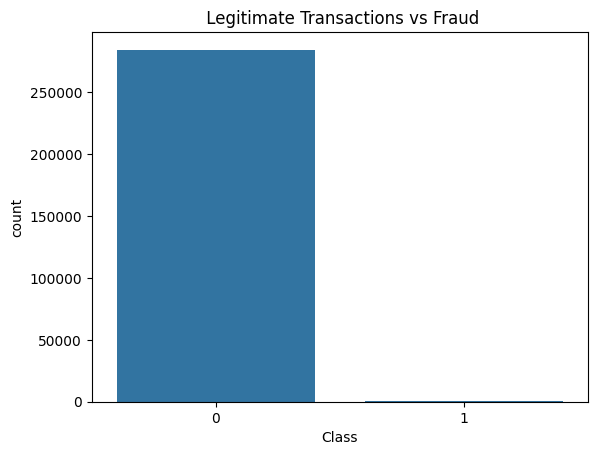

In [15]:
print(Credit_card_fraud['Class'].value_counts())

sns.countplot(x='Class', data=Credit_card_fraud)
plt.title(" Legitimate Transactions vs Fraud")
plt.show()

Transaction Amount Distribution

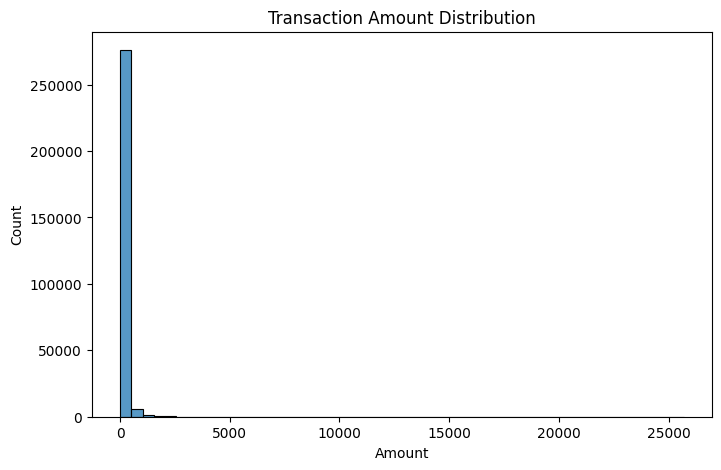

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(Credit_card_fraud['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Corelation matrix

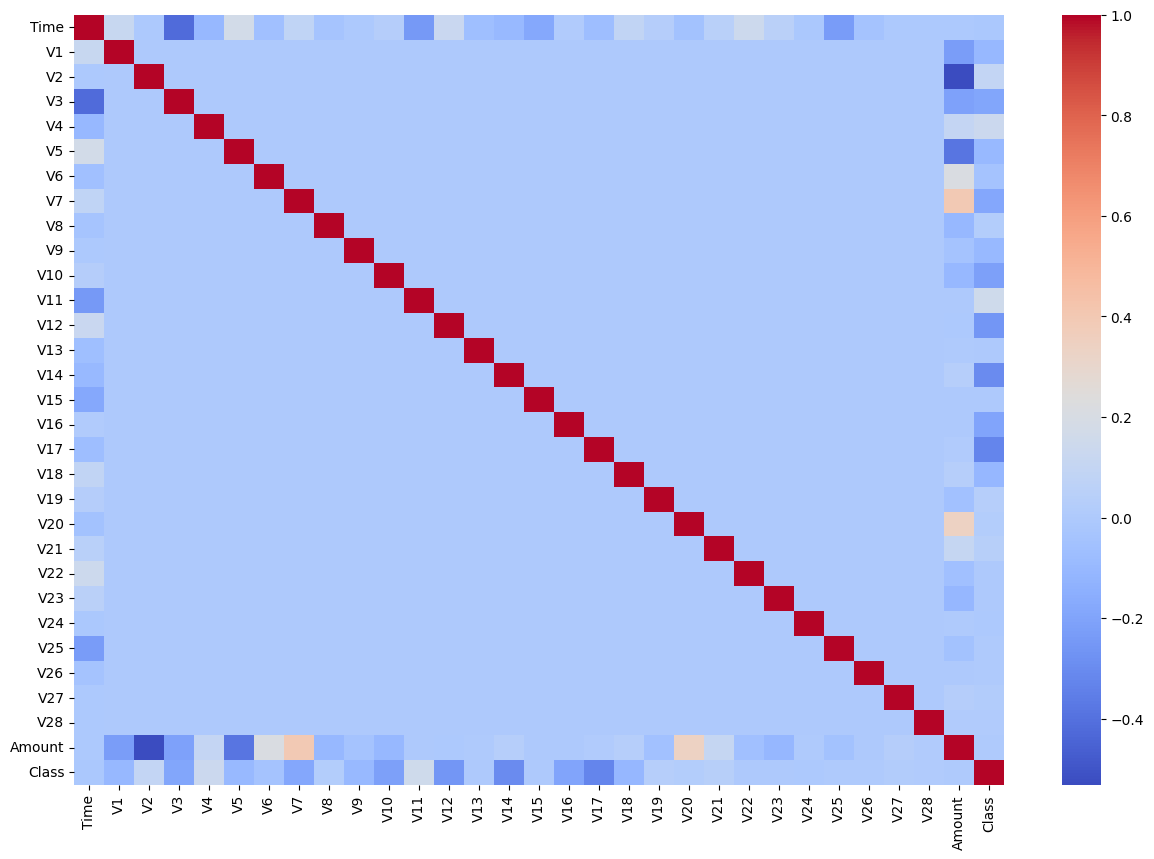

In [17]:
plt.figure(figsize=(15,10))
sns.heatmap(Credit_card_fraud.corr(), cmap='coolwarm')
plt.show()

**Step 3**: Feature scaling

In [18]:
scaler = StandardScaler()

Credit_card_fraud['Amount'] = scaler.fit_transform(
    Credit_card_fraud[['Amount']]
)

Credit_card_fraud['Time'] = scaler.fit_transform(
    Credit_card_fraud[['Time']]
)

**Step 4**:Split Features and target

In [19]:
X = Credit_card_fraud.drop('Class', axis=1)
y = Credit_card_fraud['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**step 5**: Handle class Imbalance using SMOTE

In [20]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


**Step 6**: Train Logistic Regression Model

In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

**Stpe 7**: Predictions

In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

**step 8**: Evaluation metrics

Confusion matrix

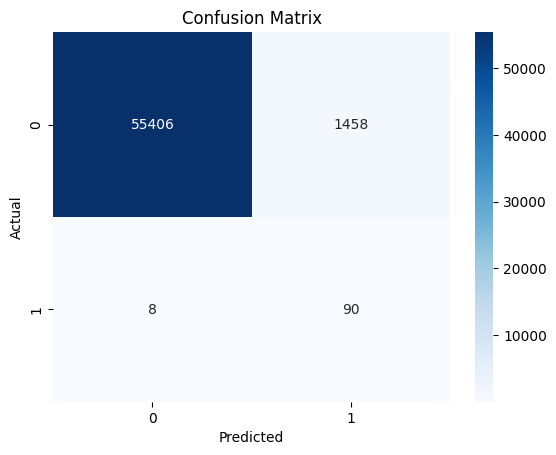

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



ROC-AUC Score

In [25]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9698482164390798


ROC Curve

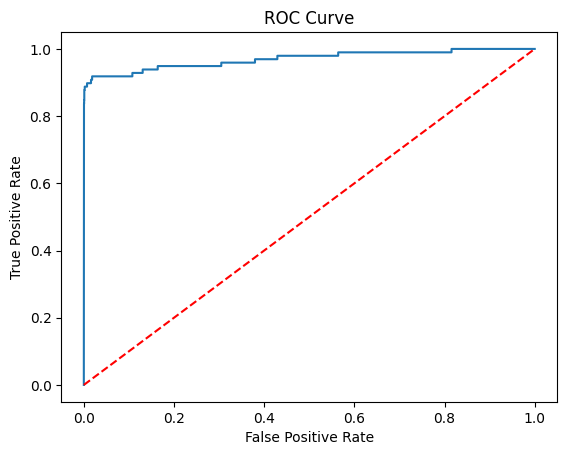

In [26]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**step 9**: Real-Time Fraud Detection

In [27]:
sample_transactions = X_test.iloc[:200]

predictions = model.predict(
    sample_transactions
)

for i, pred in enumerate(predictions):

    if pred == 1:
        print(
            f"Transaction {i+1}: FRAUD DETECTED"
        )
    else:
        print(
            f"Transaction {i+1}: Legitimate"
        )

Transaction 1: Legitimate
Transaction 2: Legitimate
Transaction 3: Legitimate
Transaction 4: Legitimate
Transaction 5: FRAUD DETECTED
Transaction 6: Legitimate
Transaction 7: Legitimate
Transaction 8: Legitimate
Transaction 9: Legitimate
Transaction 10: Legitimate
Transaction 11: Legitimate
Transaction 12: Legitimate
Transaction 13: Legitimate
Transaction 14: Legitimate
Transaction 15: Legitimate
Transaction 16: Legitimate
Transaction 17: Legitimate
Transaction 18: Legitimate
Transaction 19: Legitimate
Transaction 20: FRAUD DETECTED
Transaction 21: Legitimate
Transaction 22: Legitimate
Transaction 23: Legitimate
Transaction 24: Legitimate
Transaction 25: Legitimate
Transaction 26: Legitimate
Transaction 27: Legitimate
Transaction 28: Legitimate
Transaction 29: Legitimate
Transaction 30: Legitimate
Transaction 31: FRAUD DETECTED
Transaction 32: Legitimate
Transaction 33: Legitimate
Transaction 34: Legitimate
Transaction 35: Legitimate
Transaction 36: Legitimate
Transaction 37: Legitimat

**Model 2** : XGBoost

In [28]:
# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


In [29]:
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Prediction

In [30]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

Evaluation

In [31]:
print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob_xgb))

ROC-AUC Score: 0.9769186128306133


In [32]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb
))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.89      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_xgb
))


Confusion Matrix:
[[56814    50]
 [   11    87]]


ROC Curve

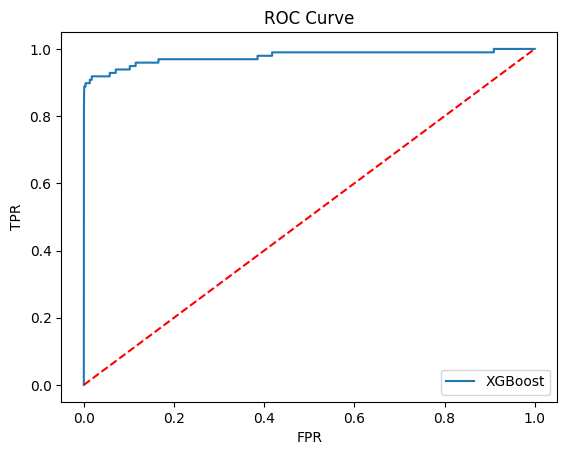

In [34]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.plot(fpr, tpr,
         label="XGBoost")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()